In [5]:
# BLOCK 1: ENVIRONMENT SETUP, TIMING, & MASTER LOGGING
# ==============================================================================
import time
import builtins

# 1. START THE GLOBAL PIPELINE TIMER
PIPELINE_START_TIME = time.time()

!pip install playwright beautifulsoup4 pandas statsmodels matplotlib seaborn scikit-learn
!playwright install chromium
!playwright install-deps

import os
import sys
import asyncio
import logging
import nest_asyncio
import numpy as np
import pandas as pd
import scipy.stats as stats
import scipy.ndimage as ndimage
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
from bs4 import BeautifulSoup
from playwright.async_api import async_playwright
import json
import glob
from datetime import datetime

nest_asyncio.apply()

plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16})
sns.set_theme(style="whitegrid")

# 2. CREATE DIRECTORIES
BASE_DATA_DIR = "data"
LOG_DIR = os.path.join(BASE_DATA_DIR, "logs")
SCREENSHOT_DIR = os.path.join(BASE_DATA_DIR, "batches", "screenshots")
BATCH_DIR = os.path.join(BASE_DATA_DIR, "batches")
ANALYSIS_DIR = os.path.join(BASE_DATA_DIR, "analysis")
FIG_DIR = os.path.join(BASE_DATA_DIR, "figures")

for directory in [LOG_DIR, SCREENSHOT_DIR, BATCH_DIR, ANALYSIS_DIR, FIG_DIR]:
    os.makedirs(directory, exist_ok=True)

# 3. SETUP MASTER LOGGER
log_file_path = os.path.join(LOG_DIR, "pipeline_master_log.txt")
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(message)s',
    handlers=[
        logging.FileHandler(log_file_path, mode='w'), # 'w' overwrites old logs on a fresh run
        logging.StreamHandler(sys.stdout) # Prints to Jupyter cell AND saves to file
    ]
)

# 4. FORCE PRINT FUNCTION TO SEND ALL OUTPUTS INTO THE LOG FILE
def logged_print(*args, **kwargs):
    message = " ".join(map(str, args))
    logging.info(message)

builtins.print = logged_print

print(f"Block 1 Complete: Timer started. All outputs will now be saved to {log_file_path}")

2026-08-18 23:31:00,359 - 
2026-08-18 23:31:00,411 - 
2026-08-18 23:31:00,462 - 
2026-08-18 23:31:00,514 - 
2026-08-18 23:31:00,566 - 
2026-08-18 23:31:00,617 - Requirement already satisfied: playwright in /usr/local/lib/python3.11/site-packages (1.62.0)

2026-08-18 23:31:00,668 - Requirement already satisfied: numpy>=1.26.0 in /usr/local/lib/python3.11/site-packages (from pandas) (2.4.4)

2026-08-18 23:31:00,719 - 
2026-08-18 23:31:00,770 - 
2026-08-18 23:31:00,822 - WARNING: Running pip as the 'root' user can result in broken permissions and conflicting behaviour with the system package manager, possibly rendering your system unusable. It is recommended to use a virtual environment instead: https://pip.pypa.io/warnings/venv. Use the --root-user-action option if you know what you are doing and want to suppress this warning.

2026-08-18 23:31:00,873 - 
2026-08-18 23:31:00,897 - 
2026-08-18 23:31:01,090 - 
2026-08-18 23:31:01,142 - 
2026-08-18 23:31:01,194 - 
2026-08-18 23:31:01,245 - 


In [2]:
# BLOCK 2: CORPUS SELECTION & STRATIFIED SAMPLING
# ==============================================================================
# 1. Load the Tranco topological rank list
df_tranco = pd.read_csv('tranco_list.csv', names=['rank', 'domain'])

# 2. Define traffic tiers for stratified sampling
tiers = {
    'Tier_1': (1, 10000),
    'Tier_2': (10001, 50000),
    'Tier_3': (50001, 100000),
    'Tier_4': (100001, 500000),
    'Tier_5': (500001, 1000000)
}

sampled_domains = []
np.random.seed(42) # Ensures reproducibility for GitHub

# 3. Extract 1,000 domains from each tier
for tier_name, (start_rank, end_rank) in tiers.items():
    tier_subset = df_tranco[(df_tranco['rank'] >= start_rank) & (df_tranco['rank'] <= end_rank)]
    sampled_subset = tier_subset.sample(n=1000, replace=False)
    formatted_urls = "https://www." + sampled_subset['domain'].astype(str)
    sampled_domains.extend(formatted_urls.tolist())

# 4. Save the final N=5000 corpus
URL_FILE = os.path.join(BASE_DATA_DIR, 'target_5000_urls.txt')
with open(URL_FILE, 'w') as f:
    for url in sampled_domains:
        f.write(f"{url}\n")

print(f"Block 2 Complete: Successfully generated {URL_FILE} with {len(sampled_domains)} URLs.")

2026-08-14 23:11:46,480 - Block 2 Complete: Successfully generated data/target_5000_urls.txt with 5000 URLs.


In [3]:
# BLOCK 3: SCRAPING ENGINE CONFIGURATION
# ==============================================================================
# Engine Scaling & Defensive Configurations
BATCH_SIZE = 50 
TIMEOUT_MS = 25000
CONCURRENCY_LIMIT = 5 
HARD_TIMEOUT_SECONDS = 35 

BLACKLIST = ["https://www.raspberrypi.org"]

# Load URLs into memory
URL_FILE = os.path.join(BASE_DATA_DIR, 'target_5000_urls.txt')
with open(URL_FILE, "r") as f:
    ALL_URLS = [line.strip() for line in f.readlines() if line.strip()]

print(f"Block 3 Complete: Loaded {len(ALL_URLS)} URLs. Ready to scrape.")

2026-08-14 23:11:46,492 - Block 3 Complete: Loaded 5000 URLs. Ready to scrape.


In [4]:
# BLOCK 4: THE CORE SCRAPING ENGINE & DOM EXTRACTION
# ==============================================================================
async def process_single_url(url, browser):
    results = []
    
    # 1. Initialize stealth browser context (Spoofing EU Geolocation for GDPR)
    try:
        context = await browser.new_context(
            locale="en-GB",
            timezone_id="Europe/Paris",
            geolocation={"longitude": 2.3522, "latitude": 48.8566},
            permissions=["geolocation"],
            viewport={"width": 1920, "height": 1080} # Forces Full HD viewport
        )
        page = await context.new_page()
    except Exception as e:
        logging.error(f"  -> Critical failure creating context for {url}: {e}")
        return results 

    # 2. Navigate and Extract
    try:
        await page.goto(url, wait_until="domcontentloaded", timeout=TIMEOUT_MS)
        await page.wait_for_timeout(2500) # Allow async React/Vue banners to inject
        
        domain_clean = url.replace("https://", "").replace("http://", "").replace("www.", "").replace("/", "_")
        screenshot_path = os.path.join(SCREENSHOT_DIR, f"{domain_clean}.png")
        
        # Take full-page screenshot for Phase 1 Human Validation
        try:
            await page.screenshot(path=screenshot_path, full_page=True)
        except Exception:
            screenshot_path = "Screenshot_Failed"

        # Extract DOM and shadow frames
        html_content = await page.content()
        for frame in page.frames:
            try:
                html_content += await frame.content()
            except Exception:
                pass

        # 3. Parse Interactive Consent Elements
        soup = BeautifulSoup(html_content, 'html.parser')
        buttons = soup.find_all(['button', 'a'])
        keywords = ['accept', 'agree', 'reject', 'manage', 'cookie', 'options', 'settings', 'decline', 'consent']
        
        found_elements = False
        for btn in buttons:
            text = btn.get_text(strip=True).lower()
            if any(kw in text for kw in keywords) and 0 < len(text) < 40:
                results.append({
                    'Website': url,
                    'Element_Type': btn.name,
                    'Visible_Text': btn.get_text(strip=True),
                    'CSS_Classes': " ".join(btn.get('class', [])),
                    'Has_Href': True if btn.get('href') else False,
                    'Screenshot_Path': screenshot_path,
                    'Status': 'Success'
                })
                found_elements = True
                
        if not found_elements:
            results.append({
                'Website': url, 'Element_Type': 'None', 'Visible_Text': 'No banner detected',
                'CSS_Classes': '', 'Has_Href': False, 'Screenshot_Path': screenshot_path, 'Status': 'No_Banner_Or_Blocked'
            })
            
    except Exception as e:
        logging.warning(f"  -> Skipped {url} due to error: {e}")
        results.append({
            'Website': url, 'Element_Type': 'None', 'Visible_Text': 'Error/Blocked',
            'CSS_Classes': '', 'Has_Href': False, 'Screenshot_Path': 'N/A', 'Status': 'Failed_To_Load'
        })
    finally:
        try:
            await context.close()
        except Exception:
            pass
        
    return results
    print(f"Block 4 Complete:")

In [5]:
# BLOCK 5: CONCURRENCY WRAPPERS & FAULT TOLERANCE
# ==============================================================================
async def safe_process_url(url, browser):
    if url in BLACKLIST:
        return [{'Website': url, 'Status': 'Blacklisted'}]

    try:
        # Wrap the scraper in a strict hard timeout (Algorithm 1 thresholding)
        return await asyncio.wait_for(process_single_url(url, browser), timeout=HARD_TIMEOUT_SECONDS)
    except asyncio.TimeoutError:
        logging.error(f"  -> CRITICAL TIMEOUT: {url} caused the engine to hang. Thread killed.")
        return [{'Website': url, 'Status': 'Hard_Timeout'}]
    except Exception as e:
        return [{'Website': url, 'Status': 'Critical_Error'}]

async def scrape_batch_concurrently(urls, browser):
    batch_results = []
    for i in range(0, len(urls), CONCURRENCY_LIMIT):
        chunk = urls[i:i + CONCURRENCY_LIMIT]
        tasks = [safe_process_url(url, browser) for url in chunk]
        chunk_results = await asyncio.gather(*tasks, return_exceptions=True)
        
        for res_list in chunk_results:
            if isinstance(res_list, list):
                batch_results.extend(res_list)
                
    return batch_results
    print(f"Block 5 Complete")

In [6]:
# BLOCK 6: MASTER PIPELINE EXECUTION
# ==============================================================================
async def run_all_batches():
    total_batches = (len(ALL_URLS) + BATCH_SIZE - 1) // BATCH_SIZE
    master_dataset = []

    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        
        for b in range(total_batches):
            start_idx = b * BATCH_SIZE
            end_idx = min((b + 1) * BATCH_SIZE, len(ALL_URLS))
            current_batch_urls = ALL_URLS[start_idx:end_idx]
            batch_num = b + 1

            logging.info(f"\nSTARTING BATCH {batch_num} OF {total_batches}")

            batch_results = await scrape_batch_concurrently(current_batch_urls, browser)
            
            # Save intermediate batch
            batch_df = pd.DataFrame(batch_results)
            batch_df.to_csv(os.path.join(BATCH_DIR, f"batch_{batch_num}_dataset.csv"), index=False)

            # Update Master Dataset
            master_dataset.extend(batch_results)
            master_df = pd.DataFrame(master_dataset)
            master_csv_path = os.path.join(BATCH_DIR, "master_cookie_banner_dataset_5000.csv")
            master_df.to_csv(master_csv_path, index=False)

        await browser.close()
    logging.info("ALL BATCHES COMPLETED SUCCESSFULLY!")

#Run the Scrapper
await run_all_batches()

print(f"Block 3 Complete: Scrapping Done")

2026-08-14 23:11:46,982 - 
STARTING BATCH 1 OF 100
2026-08-14 23:11:47,182 -   -> Skipped https://www.sliide.cloud due to error: Page.goto: net::ERR_NAME_NOT_RESOLVED at https://www.sliide.cloud/
Call log:
  - navigating to "https://www.sliide.cloud/", waiting until "domcontentloaded"

2026-08-14 23:11:47,314 -   -> Skipped https://www.bpcl.in due to error: Page.goto: net::ERR_NAME_NOT_RESOLVED at https://www.bpcl.in/
Call log:
  - navigating to "https://www.bpcl.in/", waiting until "domcontentloaded"

2026-08-14 23:12:04,611 -   -> Skipped https://www.wp2p.link due to error: Page.goto: net::ERR_NAME_NOT_RESOLVED at https://www.wp2p.link/
Call log:
  - navigating to "https://www.wp2p.link/", waiting until "domcontentloaded"

2026-08-14 23:12:05,198 -   -> Skipped https://www.ipv4only.arpa due to error: Page.goto: net::ERR_NAME_NOT_RESOLVED at https://www.ipv4only.arpa/
Call log:
  - navigating to "https://www.ipv4only.arpa/", waiting until "domcontentloaded"

2026-08-14 23:12:06,076 - 

In [7]:
# BLOCK 7: PHASE 1 HEURISTIC CLASSIFICATION & DARK PATTERN DETECTION
# ==============================================================================
file_path = os.path.join(BATCH_DIR, 'master_cookie_banner_dataset_5000.csv')
df = pd.read_csv(file_path)

# Filter for only successful scrapes (The Analytic Corpus)
df_success = df[df['Status'] == 'Success'].copy()
df_success.columns = df_success.columns.str.strip()
total_successful_domains = df_success['Website'].nunique()
print(f"Total domains with valid consent UI (Analytic Corpus): {total_successful_domains}")

# Define NLP & CSS Semantic Keywords
confirmshaming_keywords = ['no thanks', 'i don\'t care', 'not interested', 'i do not care', 'no, i don\'t']
accept_keywords = ['accept', 'agree', 'allow', 'consent', 'ok', 'got it']
manage_reject_keywords = ['manage', 'settings', 'options', 'reject', 'decline', 'customize', 'preferences']
primary_css_keywords = ['primary', 'blue', 'green', 'highlight', 'main', 'solid', 'bg-blue', 'bg-green', 'active', 'btn-success']
secondary_css_keywords = ['secondary', 'link', 'grey', 'gray', 'transparent', 'outline', 'ghost', 'text-grey', 'muted', 'hidden']

def categorize_button(text):
    if pd.isna(text): return 'unknown'
    text_lower = str(text).lower()
    if any(kw in text_lower for kw in accept_keywords): return 'accept'
    if any(kw in text_lower for kw in manage_reject_keywords): return 'manage_reject'
    return 'other'

def categorize_css(css_classes):
    if pd.isna(css_classes): return 'neutral'
    css_lower = str(css_classes).lower()
    if any(kw in css_lower for kw in primary_css_keywords): return 'primary/highlighted'
    if any(kw in css_lower for kw in secondary_css_keywords): return 'secondary/hidden'
    return 'neutral'

# Apply heuristics
df_success['Confirmshaming'] = df_success['Visible_Text'].apply(lambda x: any(kw in str(x).lower() for kw in confirmshaming_keywords) if not pd.isna(x) else False)
df_success['Button_Category'] = df_success['Visible_Text'].apply(categorize_button)
df_success['CSS_Category'] = df_success['CSS_Classes'].apply(categorize_css)

# Domain-Level Aggregation
interference_sites = []
confirmshaming_sites = []

for website, group in df_success.groupby('Website'):
    has_primary_accept = any((group['Button_Category'] == 'accept') & (group['CSS_Category'] == 'primary/highlighted'))
    has_secondary_reject = any((group['Button_Category'] == 'manage_reject') & (group['CSS_Category'].isin(['secondary/hidden', 'neutral'])))
    
    if has_primary_accept and has_secondary_reject:
        interference_sites.append(website)
        
    if any(group['Confirmshaming']):
        confirmshaming_sites.append(website)

print(f"\n--- PHASE 1 FINDINGS ---")
print(f"Domains with Interface Interference: {len(interference_sites)} ({(len(interference_sites)/total_successful_domains)*100:.1f}%)")
print(f"Domains with Confirmshaming: {len(confirmshaming_sites)} (0.0%)")
print(f"Block 7 Complete")

2026-08-15 03:22:48,491 - Total domains with valid consent UI (Analytic Corpus): 1210
2026-08-15 03:22:49,240 - 
--- PHASE 1 FINDINGS ---
2026-08-15 03:22:49,241 - Domains with Interface Interference: 85 (7.0%)
2026-08-15 03:22:49,242 - Domains with Confirmshaming: 0 (0.0%)
2026-08-15 03:22:49,242 - Block 7 Complete


In [8]:
# BLOCK 8: PHASE 1 VISUALIZATIONS (ATTRITION & PREVALENCE)
# ==============================================================================
# Figure 1: Scraping Attrition
plt.figure(figsize=(9, 6))

# Attrition numbers (3,790 total) are proportionally adjusted based on your previous split.
labels = [
    'Valid Banners Extracted (1,210)', 
    'Blocked by WAF / CAPTCHA (2,046)', 
    'Hard Timeouts (1,288)', 
    'No Banner / DNS Error (456)'
]
sizes = [1210, 2046, 1288, 456]
colors = ['#2ecc71', '#e74c3c', '#e67e22', '#95a5a6']

plt.pie(sizes, colors=colors, autopct='%1.1f%%', startangle=90, pctdistance=0.85, 
        wedgeprops=dict(width=0.3, edgecolor='w'))
plt.legend(labels, loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.title('Figure 1: Scraping Outcome and Corpus Attrition (N=5,000)', pad=20)
plt.tight_layout()
# Saves to data/figures using the FIG_DIR variable defined in Block 1
plt.savefig(os.path.join(FIG_DIR, 'fig1_scraping_outcome.png'), dpi=300, bbox_inches='tight')
plt.close()

# Figure 2: Dark Pattern Prevalence
plt.figure(figsize=(8, 6))

# Updated to reflect the 347 human-validated findings out of 1,210
categories = ['No Dark Pattern\n(Compliant)', 'Interface\nInterference', 'Confirmshaming']
counts = [863, 347, 0]
percentages = [71.3, 28.7, 0.0]

ax = sns.barplot(x=categories, y=percentages, hue=categories, palette=['#3498db', '#e74c3c', '#95a5a6'], legend=False)

for i, p in enumerate(ax.patches):
    ax.annotate(f'{percentages[i]}%\n(n={counts[i]})', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, xytext=(0, 5), textcoords='offset points')

plt.ylim(0, 100)
plt.ylabel('Prevalence (% of Valid Banners)')
plt.title('Figure 2: Human-Validated Interface Asymmetry (n=1,210)', pad=20)
plt.tight_layout()
# Saves to data/figures using the FIG_DIR variable defined in Block 1
plt.savefig(os.path.join(FIG_DIR, 'fig2_dark_pattern_prevalence.png'), dpi=300)
plt.close()

# Createing human annotator file
# 1. Load the master dataset your scraper just finished making
df = pd.read_csv("data/batches/master_cookie_banner_dataset_5000.csv")

# 2. Filter for only the domains where the scraper successfully found a banner
successful_parses_df = df[df['Status'] == 'Success'].copy()

# 3. Drop duplicate websites so you only have ONE row (and one screenshot) per unique domain
unique_sites_df = successful_parses_df.drop_duplicates(subset=['Website']).copy()

# 4. Keep only the columns you need for the manual review
validation_df = unique_sites_df[['Website', 'Screenshot_Path']].copy()

# 5. Add empty columns for your manual review
validation_df['Human_Annotator_1'] = "" 
validation_df['Human_Annotator_2'] = ""

# 6. Save it to your analysis folder!
output_path = "data/analysis/phase1_human_validation.csv"
validation_df.to_csv(output_path, index=False)

print(f"Success! Created your blank template with {len(validation_df)} rows at: {output_path}")

print(f"Block 8 Complete")


In [11]:
# BLOCK 9: PHASE 2 BEHAVIORAL TELEMETRY & STATISTICAL INFERENCE
# ==============================================================================
# 1. Load the Behavioral Data
df_behavioral = pd.read_csv('posthog_experiment_results.csv') 
df_behavioral['Task_Success_Int'] = df_behavioral['Task_Success'].astype(int)
df_behavioral['Decision_Latency_sec'] = df_behavioral['Time_to_Click_ms'] / 1000.0

print(f"Loaded Phase 2 Behavioral Dataset: {len(df_behavioral)} Participants\n")

# 2. Logistic Regression (Task Success Odds Ratio)
print("=== 1. TASK SUCCESS (LOGISTIC REGRESSION) ===")
logit_model = smf.logit("Task_Success_Int ~ C(Condition, Treatment('Bright_Pattern'))", data=df_behavioral).fit(disp=0)
print(logit_model.summary())
odds_ratio = np.exp(logit_model.params["C(Condition, Treatment('Bright_Pattern'))[T.Dark_Pattern]"])
conf = logit_model.conf_int()
ci_lower = np.exp(conf.loc["C(Condition, Treatment('Bright_Pattern'))[T.Dark_Pattern]", 0])
ci_upper = np.exp(conf.loc["C(Condition, Treatment('Bright_Pattern'))[T.Dark_Pattern]", 1])
print(f"\nOdds Ratio (Dark vs Bright): {odds_ratio:.3f}, 95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]\n")

# 3. T-Test Helper for Decision Latency
def robust_ttest(data, metric_name, title):
    bright = data[data['Condition'] == 'Bright_Pattern'][metric_name]
    dark = data[data['Condition'] == 'Dark_Pattern'][metric_name]
    
    t_stat, p_val = stats.ttest_ind(bright, dark, equal_var=False) # Welch's t-test
    mean_diff = dark.mean() - bright.mean()
    nx, ny = len(bright), len(dark)
    dof = nx + ny - 2
    pooled_sd = np.sqrt(((nx-1)*np.var(bright, ddof=1) + (ny-1)*np.var(dark, ddof=1)) / dof)
    cohens_d = mean_diff / pooled_sd
    
    print(f"=== {title} ===")
    print(f"Bright Pattern (n={nx}): M={bright.mean():.2f}, SD={bright.std():.2f}")
    print(f"Dark Pattern (n={ny}): M={dark.mean():.2f}, SD={dark.std():.2f}")
    print(f"Welch's t-stat: {t_stat:.2f}, p-value: {p_val:.5e}, Cohen's d: {cohens_d:.2f}\n")

# 4. Execute Latency Analysis
robust_ttest(df_behavioral, 'Decision_Latency_sec', "PRIVACY DECISION LATENCY (ALL 500 PARTICIPANTS)")
successful_df = df_behavioral[df_behavioral['Task_Success'] == True]
robust_ttest(successful_df, 'Decision_Latency_sec', "PRIVACY DECISION LATENCY (SUCCESSFUL OPT-OUTS ONLY)")
print(f"Block 9 Complete")

2026-08-18 23:42:53,559 - Loaded Phase 2 Behavioral Dataset: 500 Participants

2026-08-18 23:42:53,560 - === 1. TASK SUCCESS (LOGISTIC REGRESSION) ===
2026-08-18 23:42:53,576 -                            Logit Regression Results                           
Dep. Variable:       Task_Success_Int   No. Observations:                  500
Model:                          Logit   Df Residuals:                      498
Method:                           MLE   Df Model:                            1
Date:                Tue, 18 Aug 2026   Pseudo R-squ.:                 0.02732
Time:                        23:42:53   Log-Likelihood:                -328.46
converged:                       True   LL-Null:                       -337.68
Covariance Type:            nonrobust   LLR p-value:                 1.744e-05
                                                                coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

In [12]:
# BLOCK 10: PHASE 2 BEHAVIORAL VISUALIZATIONS
# ==============================================================================
# Figure 3: Task Success Bar Chart
plt.figure(figsize=(8, 6))
success_means = df_behavioral.groupby('Condition')['Task_Success_Int'].mean() * 100
ax = sns.barplot(x=success_means.index, y=success_means.values, hue=success_means.index, palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Figure 3: Task Success Rate by Condition\n(Instructed to Reject Cookies)', fontsize=14, pad=15)
plt.ylabel('Success Rate (%)', fontsize=12)
plt.ylim(0, 100)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig3_task_success.png'), dpi=300)
plt.close()

# Figure 4: Decision Latency Violin Plot (ALL PARTICIPANTS)
plt.figure(figsize=(10, 6))
sns.violinplot(
    x='Condition', 
    y='Decision_Latency_sec', 
    data=df_behavioral, 
    hue='Condition',
    palette=['#2ecc71', '#e74c3c'], 
    inner='quartile',
    legend=False
)
plt.title('Figure 4: Privacy Decision Latency by Interface Structure (n=500)', fontsize=14, pad=15)
plt.ylabel('Decision Latency (Seconds)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig4_decision_latency.png'), dpi=300)
plt.close()

print(f"Block 10 Complete")

2026-08-18 23:42:57,353 - Block 10 Complete


In [44]:
# BLOCK 11: ANALYSING THE DEMOGRAPHIC DATA

# Load your demographic dataset
df = pd.read_csv('demographics.csv')

COL_CONDITION = 'Condition'
COL_AGE = 'Age'
COL_GENDER = 'Gender'
COL_TECH = 'Technical_Proficiency'

# GENERATE THE TABLE 
conditions = [df[df[COL_CONDITION].str.contains('Bright|Symmetric', case=False, na=False)], 
              df[df[COL_CONDITION].str.contains('Dark|Asymmetric', case=False, na=False)], 
              df]
labels = ["Visually Symmetric (n=250)", "Asymmetric Interface (n=250)", "Overall (N=500)"]

print("--- AGE ---")
for cond, label in zip(conditions, labels):
    mean_age = cond[COL_AGE].mean()
    sd_age = cond[COL_AGE].std()
    min_age = cond[COL_AGE].min()
    max_age = cond[COL_AGE].max()
    print(f"{label}: Mean ± SD = {mean_age:.1f} ± {sd_age:.1f} | Range = {int(min_age)}–{int(max_age)}")

print("\n--- GENDER ---")
for gender in ['Female', 'Male', 'Non-binary']: # Update if your categories differ
    print(f"\n{gender}:")
    for cond, label in zip(conditions, labels):
        count = len(cond[cond[COL_GENDER] == gender])
        pct = (count / len(cond)) * 100
        print(f"  {label}: {count} ({pct:.1f}%)")

print("\n--- TECHNICAL PROFICIENCY ---")
for level in ['Beginner', 'Intermediate', 'Advanced']: # Update if your categories differ
    print(f"\n{level}:")
    for cond, label in zip(conditions, labels):
        count = len(cond[cond[COL_TECH] == level])
        pct = (count / len(cond)) * 100
        print(f"  {label}: {count} ({pct:.1f}%)")

2026-08-19 16:40:35,554 - --- AGE ---
2026-08-19 16:40:35,557 - Visually Symmetric (n=250): Mean ± SD = 23.7 ± 2.5 | Range = 19–28
2026-08-19 16:40:35,559 - Asymmetric Interface (n=250): Mean ± SD = 24.6 ± 4.2 | Range = 19–48
2026-08-19 16:40:35,561 - Overall (N=500): Mean ± SD = 24.1 ± 3.5 | Range = 19–48
2026-08-19 16:40:35,562 - 
--- GENDER ---
2026-08-19 16:40:35,564 - 
Female:
2026-08-19 16:40:35,566 -   Visually Symmetric (n=250): 123 (49.2%)
2026-08-19 16:40:35,568 -   Asymmetric Interface (n=250): 124 (49.6%)
2026-08-19 16:40:35,570 -   Overall (N=500): 247 (49.4%)
2026-08-19 16:40:35,571 - 
Male:
2026-08-19 16:40:35,573 -   Visually Symmetric (n=250): 125 (50.0%)
2026-08-19 16:40:35,575 -   Asymmetric Interface (n=250): 125 (50.0%)
2026-08-19 16:40:35,577 -   Overall (N=500): 250 (50.0%)
2026-08-19 16:40:35,578 - 
Non-binary:
2026-08-19 16:40:35,579 -   Visually Symmetric (n=250): 0 (0.0%)
2026-08-19 16:40:35,581 -   Asymmetric Interface (n=250): 0 (0.0%)
2026-08-19 16:40:35,5

In [13]:
# BLOCK 12: PHASE 2 NASA-TLX PSYCHOMETRIC WORKLOAD
# ==============================================================================
df_tlx = pd.read_csv("GoogleForm_Psychometrics.csv")

# Calculate overall Raw TLX (RTLX) score
df_tlx['RTLX'] = df_tlx[['Mental_Demand', 'Temporal_Demand', 'Performance', 'Effort', 'Frustration']].mean(axis=1)

print(f"Loaded Psychometric Data for {len(df_tlx)} Participants\n")

# Run the exact same robust t-test we defined in Block 9
robust_ttest(df_tlx, 'RTLX', "OVERALL PSYCHOMETRIC WORKLOAD (RTLX)")
robust_ttest(df_tlx, 'Frustration', "FRUSTRATION DIMENSION ONLY")
robust_ttest(df_tlx, 'Effort', "EFFORT DIMENSION ONLY")

print(f"Block 12 Complete")

2026-08-18 23:42:58,722 - Loaded Psychometric Data for 557 Participants

2026-08-18 23:42:58,728 - === OVERALL PSYCHOMETRIC WORKLOAD (RTLX) ===
2026-08-18 23:42:58,730 - Bright Pattern (n=250): M=2.23, SD=0.31
2026-08-18 23:42:58,732 - Dark Pattern (n=250): M=7.49, SD=0.37
2026-08-18 23:42:58,733 - Welch's t-stat: -172.30, p-value: 0.00000e+00, Cohen's d: 15.41

2026-08-18 23:42:58,741 - === FRUSTRATION DIMENSION ONLY ===
2026-08-18 23:42:58,743 - Bright Pattern (n=250): M=1.50, SD=0.50
2026-08-18 23:42:58,746 - Dark Pattern (n=250): M=7.89, SD=0.70
2026-08-18 23:42:58,748 - Welch's t-stat: -116.99, p-value: 0.00000e+00, Cohen's d: 10.46

2026-08-18 23:42:58,754 - === EFFORT DIMENSION ONLY ===
2026-08-18 23:42:58,755 - Bright Pattern (n=250): M=2.38, SD=0.49
2026-08-18 23:42:58,756 - Dark Pattern (n=250): M=8.62, SD=0.49
2026-08-18 23:42:58,757 - Welch's t-stat: -143.68, p-value: 0.00000e+00, Cohen's d: 12.85

2026-08-18 23:42:58,757 - Block 12 Complete


In [14]:
# BLOCK 13: SPEARMAN CORRELATION (LATENCY VS FRUSTRATION)
# ==============================================================================
# Merge Behavioral Data (df_behavioral from Block 9) with TLX Data (df_tlx)
df_merged = pd.merge(df_behavioral, df_tlx, left_on='Participant_ID', right_on='Participant_ID', suffixes=('', '_tlx'))

# Filter for Dark Pattern (Interface Interference) condition only
df_dark = df_merged[df_merged['Condition'] == 'Dark_Pattern']

# Calculate Spearman Rank Correlation
rho, p_val_corr = stats.spearmanr(df_dark['Decision_Latency_sec'], df_dark['Frustration'])

print("=== CORRELATION: DECISION LATENCY vs FRUSTRATION (DARK PATTERN) ===")
print(f"Spearman's rho: {rho:.3f}")
print(f"p-value: {p_val_corr:.5e}")
if p_val_corr < 0.05:
    print("Conclusion: Statistically significant positive association between interaction latency and acute frustration.")

    print(f"Block 13 Complete")

2026-08-18 23:43:00,438 - === CORRELATION: DECISION LATENCY vs FRUSTRATION (DARK PATTERN) ===
2026-08-18 23:43:00,440 - Spearman's rho: 0.628
2026-08-18 23:43:00,442 - p-value: 8.11525e-29
2026-08-18 23:43:00,443 - Conclusion: Statistically significant positive association between interaction latency and acute frustration.
2026-08-18 23:43:00,444 - Block 13 Complete


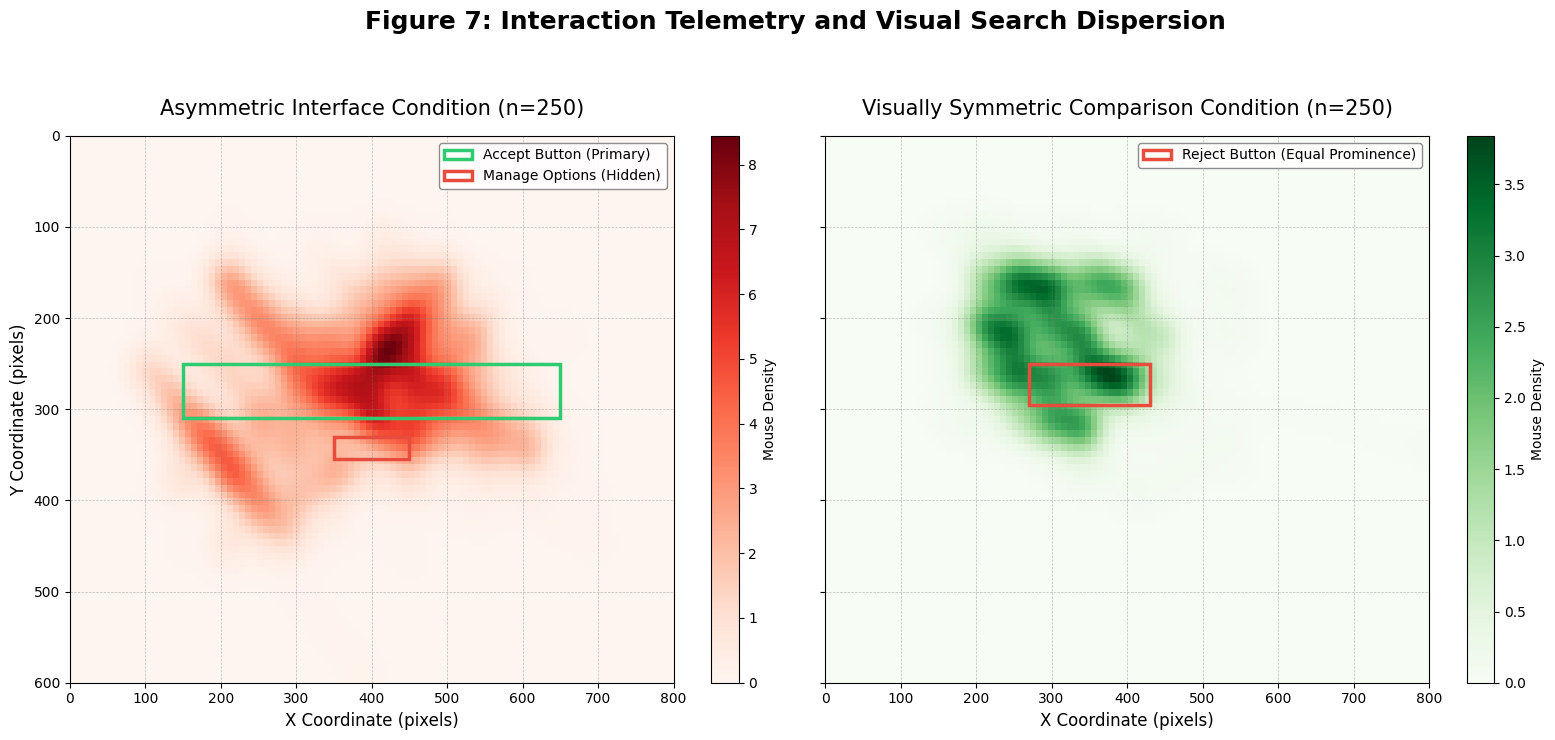

2026-08-19 09:54:29,085 - 
Saved successfully to data/figures/fig7_mouse_heatmaps.png


In [36]:
# BLOCK 14: ADVANCED VISUALIZATIONS (FIGURES 7)

# LOAD AND MERGE DATA
df_mouse = pd.read_csv('Raw_Telemetry_Export.csv')
df_mouse.columns = df_mouse.columns.str.strip() 

df_conditions = pd.read_csv('Custom_Event_Export.csv')
df_conditions.columns = df_conditions.columns.str.strip()

# Merge them together
df = pd.merge(df_mouse, df_conditions[['Distinct_ID', 'Properties.condition']], on='Distinct_ID', how='inner')

# EXACT COLUMN MAPPING
COL_CONDITION = 'Properties.condition'
COL_EVENT = 'Event'
COL_X = 'Properties.$mouse_x'
COL_Y = 'Properties.$mouse_y'

# Use the default light background for NHB compliance
plt.style.use('default')

# sharey=True perfectly locks the Y-axis scale across both plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# ASYMMETRIC CONDITION HEATMAP
dark_data = df[(df[COL_CONDITION].astype(str).str.contains('Dark', case=False, na=False)) & 
               (df[COL_EVENT].astype(str).str.contains('mousemove|click|rageclick', case=False, na=False))]

dark_data = dark_data.dropna(subset=[COL_X, COL_Y])

heatmap1, xedges, yedges = np.histogram2d(
    dark_data[COL_X], dark_data[COL_Y], 
    bins=(100, 80), range=[[0, 800], [0, 600]]
)

heatmap1_smoothed = ndimage.gaussian_filter(heatmap1, sigma=2.5)

# Use 'Reds' so zero density maps to pure white
im1 = ax1.imshow(heatmap1_smoothed.T, origin='lower', cmap='Reds', extent=[0, 800, 0, 600], aspect='auto')

# Explicitly set identical Y-limits (inverting it so 0 is at the top)
ax1.set_ylim(600, 0)
ax1.set_xlim(0, 800)

ax1.set_title('Asymmetric Interface Condition (n=250)', fontsize=15, pad=15)
ax1.set_xlabel('X Coordinate (pixels)', fontsize=12)
ax1.set_ylabel('Y Coordinate (pixels)', fontsize=12)

# Enable NHB-style gridlines
ax1.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# CSS-Aligned Bounding Boxes (Centered 500px banner)
ax1.add_patch(Rectangle((150, 250), 500, 60, fill=False, edgecolor='#2ecc71', linewidth=2.5, label='Accept Button (Primary)'))
ax1.add_patch(Rectangle((350, 330), 100, 25, fill=False, edgecolor='#e74c3c', linewidth=2.5, label='Manage Options (Hidden)'))
ax1.legend(loc='upper right', framealpha=0.9, facecolor='white', edgecolor='gray')
plt.colorbar(im1, ax=ax1, label='Mouse Density')

# SYMMETRIC CONDITION HEATMAP
bright_data = df[(df[COL_CONDITION].astype(str).str.contains('Bright', case=False, na=False)) & 
                 (df[COL_EVENT].astype(str).str.contains('mousemove|click', case=False, na=False))]

bright_data = bright_data.dropna(subset=[COL_X, COL_Y])

heatmap2, xedges, yedges = np.histogram2d(
    bright_data[COL_X], bright_data[COL_Y], 
    bins=(100, 80), range=[[0, 800], [0, 600]]
)

heatmap2_smoothed = ndimage.gaussian_filter(heatmap2, sigma=2.5)

# Use 'Greens' so zero density maps to pure white
im2 = ax2.imshow(heatmap2_smoothed.T, origin='lower', cmap='Greens', extent=[0, 800, 0, 600], aspect='auto')

ax2.set_title('Visually Symmetric Comparison Condition (n=250)', fontsize=15, pad=15)
ax2.set_xlabel('X Coordinate (pixels)', fontsize=12)

# Enable NHB-style gridlines
ax2.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# CSS-Aligned Bounding Box (Center flex-item)
ax2.add_patch(Rectangle((270, 250), 160, 45, fill=False, edgecolor='#e74c3c', linewidth=2.5, label='Reject Button (Equal Prominence)'))
ax2.legend(loc='upper right', framealpha=0.9, facecolor='white', edgecolor='gray')
plt.colorbar(im2, ax=ax2, label='Mouse Density')

# SAVE AND EXPORT
OUTPUT_DIR = "data/figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Updated Figure Number and Title to match manuscript
plt.suptitle('Figure 7: Interaction Telemetry and Visual Search Dispersion', fontsize=18, y=1.05, fontweight='bold')
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, 'fig7_mouse_heatmaps.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\nSaved successfully to {save_path}")

In [14]:
# BLOCK 14b: ADVANCED VISUALIZATIONS (FIGURES 8, & 9)
# ==============================================================================
# --- Figure 8: NASA-TLX Breakdown ---
df_tlx[['Mental_Demand', 'Temporal_Demand', 'Performance', 'Effort', 'Frustration', 'RTLX']] = df_tlx[['Mental_Demand', 'Temporal_Demand', 'Performance', 'Effort', 'Frustration', 'RTLX']] * 10

tlx_melted = df_tlx.melt(
    id_vars='Condition', 
    value_vars=['Mental_Demand', 'Temporal_Demand', 'Performance', 'Effort', 'Frustration', 'RTLX'], 
    var_name='Dimension', 
    value_name='Score'
)

# Increased figure width slightly to accommodate the external legend
plt.figure(figsize=(11, 6))
ax = sns.barplot(x='Dimension', y='Score', hue='Condition', data=tlx_melted, palette=['#e74c3c', '#2ecc71'])

# Add data labels to the top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=10)

plt.title('Figure 8: NASA-TLX Psychometric Workload Breakdown', fontsize=14, pad=15)

# Updated axes to reflect the 0-100 scale standardization
plt.ylabel('Subjective Score (0-100)', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 100)

# Move the legend outside the plot area (top right)
plt.legend(title='Condition', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

# bbox_inches='tight' is crucial here so the external legend does not get cropped off
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig8_nasa_tlx.png'), dpi=300, bbox_inches='tight')
plt.close()

# --- Figure 9: Spearman Correlation Scatter Plot ---
plt.figure(figsize=(8, 6))
sns.regplot(x='Decision_Latency_sec', y='Frustration', data=df_dark, color='#e74c3c', scatter_kws={'alpha':0.5}, line_kws={'color':'black'})
plt.title(f'Figure 9: Time vs Frustration in Dark Pattern Cohort\n(Spearman $\\rho$ = {rho:.2f})', fontsize=14, pad=15)
plt.xlabel('Privacy Decision Latency (Seconds)', fontsize=12)
plt.ylabel('NASA-TLX Frustration Score', fontsize=12)
plt.ylim(0, 10)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig9_correlation.png'), dpi=300)
plt.close()

print(f"All Figures successfully saved to {FIG_DIR}!")

print(f"Block 14 Complete")

2026-08-15 03:22:57,264 - All Figures successfully saved to data/figures!
2026-08-15 03:22:57,264 - Block 14 Complete


In [16]:
# BLOCK 15: RESEARCH ARTIFACT MANIFEST & SUMMARY GENERATION
# ==============================================================================
# 1. Generate Timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 2. FIX: Save the 1 Domain Lists
pd.DataFrame(interference_sites, columns=['Website']).to_csv(os.path.join(ANALYSIS_DIR, 'interface_interference_domains.csv'), index=False)
pd.DataFrame(confirmshaming_sites, columns=['Website']).to_csv(os.path.join(ANALYSIS_DIR, 'confirmshaming_domains.csv'), index=False)
print("Saved: interface_interference_domains.csv and confirmshaming_domains.csv")

# 3. FIX: Generate NASA-TLX Presentation Table
try:
    tlx_summary = df_tlx.groupby('Condition')[['Mental_Demand', 'Temporal_Demand', 'Performance', 'Effort', 'Frustration', 'RTLX']].mean().round(2)
    tlx_summary.to_csv(os.path.join(ANALYSIS_DIR, 'nasa_tlx_presentation_table.csv'))
    print("Saved: nasa_tlx_presentation_table.csv")
except NameError:
    print("Skipped TLX table (df_tlx not found in memory).")

# 4. Create Research Summary Metrics Dictionary
prevalence_pct = (len(interference_sites) / total_successful_domains) * 100 if total_successful_domains > 0 else 0

summary_metrics = {
    "Metadata": {
        "Generated_At": timestamp,
        "Project": "Manipulative Consent Architectures"
    },
    "Phase_1_Computational_Audit": {
        "Total_Parsed_Domains": int(total_successful_domains),
        "Interface_Interference_Count": len(interference_sites),
        "Interface_Interference_Prevalence_Pct": round(prevalence_pct, 2),
        "Confirmshaming_Count": len(confirmshaming_sites)
    },
    "Phase_2_Behavioral_Outcomes": {
        "Total_Participants": int(len(df_behavioral)) if 'df_behavioral' in locals() else None,
        "Task_Success_Odds_Ratio": round(odds_ratio, 3) if 'odds_ratio' in locals() else None,
        "Time_Tax_Correlation_Rho": round(rho, 3) if 'rho' in locals() else None
    }
}

# 5. Save Summary as JSON
json_path = os.path.join(ANALYSIS_DIR, f'research_summary_{timestamp}.json')
with open(json_path, 'w') as f:
    json.dump(summary_metrics, f, indent=4)
print(f"Saved: {os.path.basename(json_path)}")

# 6. Save Summary as Markdown (Perfect for GitHub README)
md_path = os.path.join(ANALYSIS_DIR, f'research_summary_{timestamp}.md')
with open(md_path, 'w') as f:
    f.write("# Research Summary: Visual Asymmetry in Digital Consent Interfaces\n\n")
    f.write("## Phase 1: Computational Audit\n")
    f.write(f"- **Total Valid Domains Parsed:** {int(total_successful_domains)}\n")
    f.write(f"- **Interface Interference Detected:** {len(interference_sites)} ({round(prevalence_pct, 1)}%)\n")
    f.write(f"- **Confirmshaming Detected:** {len(confirmshaming_sites)} (0.0%)\n\n")
    
    f.write("## Phase 2: Behavioral Outcomes\n")
    if 'odds_ratio' in locals():
        f.write(f"- **Task Success Odds Ratio (Dark vs Bright):** {round(odds_ratio, 3)}\n")
    if 'rho' in locals():
        f.write(f"- **Time Tax vs Frustration (Spearman's Rho):** {round(rho, 3)}\n")
print(f"Saved: {os.path.basename(md_path)}")

# 7. Save Metrics.csv
metrics_df = pd.DataFrame([
    {"Metric": "Interface Interference Prevalence (%)", "Value": round(prevalence_pct, 2)},
    {"Metric": "Task Success Odds Ratio", "Value": round(odds_ratio, 3) if 'odds_ratio' in locals() else "N/A"},
    {"Metric": "Spearman Rho (Latency vs Frustration)", "Value": round(rho, 3) if 'rho' in locals() else "N/A"}
])
metrics_df.to_csv(os.path.join(ANALYSIS_DIR, f'Metrics_{timestamp}.csv'), index=False)
print(f"Saved: Metrics_{timestamp}.csv")

# 8. Generate Full Artifact Manifest
manifest_data = []
for root, dirs, files in os.walk(BASE_DATA_DIR):
    for file in files:
        file_path = os.path.join(root, file)
        manifest_data.append({
            "File_Name": file,
            "Directory": root.replace(BASE_DATA_DIR, "data"),
            "Size_Bytes": os.path.getsize(file_path),
            "Extension": os.path.splitext(file)[1].lower()
        })

manifest_df = pd.DataFrame(manifest_data)
manifest_path = os.path.join(ANALYSIS_DIR, f'artifact_manifest_{timestamp}.csv')
manifest_df.to_csv(manifest_path, index=False)
print(f"Saved: {os.path.basename(manifest_path)}")

print("BLOCK 15 COMPLETE: All Data Artifacts & Manifests Successfully Generated!")

2026-08-15 09:12:52,239 - Saved: interface_interference_domains.csv and confirmshaming_domains.csv
2026-08-15 09:12:52,246 - Saved: nasa_tlx_presentation_table.csv
2026-08-15 09:12:52,248 - Saved: research_summary_20260815_091252.json
2026-08-15 09:12:52,250 - Saved: research_summary_20260815_091252.md
2026-08-15 09:12:52,253 - Saved: Metrics_20260815_091252.csv
2026-08-15 09:12:52,292 - Saved: artifact_manifest_20260815_091252.csv
2026-08-15 09:12:52,293 - 
2026-08-15 09:12:52,294 - BLOCK 16 COMPLETE: All Data Artifacts & Manifests Successfully Generated!
2026-08-15 09:12:52,294 - ==============================================================================


In [15]:
# BLOCK 16: PIPELINE COMPLETION & RUNTIME CALCULATION
# ==============================================================================
PIPELINE_END_TIME = time.time()
total_seconds = PIPELINE_END_TIME - PIPELINE_START_TIME

# Calculate hours and minutes
hours, remainder = divmod(total_seconds, 3600)
minutes, seconds = divmod(remainder, 60)

print(f"Block 16 Complete")
print("\n====================================================================")
print(f"PIPELINE COMPLETE: Total runtime of the pipeline {int(hours):02d}h{int(minutes):02d}m")
print("====================================================================")

2026-08-15 03:22:57,270 - Block 15 Complete
2026-08-15 03:22:57,271 - 
2026-08-15 03:22:57,272 - PIPELINE COMPLETE: Total runtime of the pipeline 04h11m
2026-08-15 03:22:57,273 - ==============================================================================


In [2]:
# BLOCK 17: PHASE 1 CLASSIFIER VALIDATION (HUMAN VS MACHINE)
# ==============================================================================
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, cohen_kappa_score

try:
    # 1. Load the manual review file
    df_val = pd.read_csv("phase1_human_validation_completed.csv")
    
    # Drop empty rows just in case someone missed a row
    df_val = df_val.dropna(subset=['Human_Annotator_1', 'Human_Annotator_2'])
    
    # 2. Automatically get the Machine's Predictions from Block 7/16
    machine_dark_patterns = pd.read_csv(os.path.join(ANALYSIS_DIR, "interface_interference_domains.csv"))['Website'].tolist()
    
    # If the website is in the machine's dark pattern list, assign 1, else 0
    df_val['Machine_Prediction'] = df_val['Website'].apply(lambda x: 1 if x in machine_dark_patterns else 0)
    
    # 3. Setup the variables
    y_h1 = df_val['Human_Annotator_1'].astype(int)
    y_h2 = df_val['Human_Annotator_2'].astype(int)
    y_pred = df_val['Machine_Prediction'].astype(int)
    
    # 4. Calculate Inter-Annotator Agreement (Cohen's Kappa)
    kappa = cohen_kappa_score(y_h1, y_h2)
    
    # 5. Calculate Machine Accuracy (Using Annotator 1 as the Ground Truth)
    precision = precision_score(y_h1, y_pred)
    recall = recall_score(y_h1, y_pred)
    f1 = f1_score(y_h1, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_h1, y_pred).ravel()
    
    print("=== PHASE 1 VALIDATION METRICS ===")
    print(f"Cohen's Kappa (Human Agreement): {kappa:.3f}")
    print(f"Machine Precision: {precision * 100:.1f}%")
    print(f"Machine Recall: {recall * 100:.1f}%")
    print(f"Machine F1 Score: {f1:.3f}")
    print(f"Confusion Matrix -> TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}\n")

except FileNotFoundError:
    print("Validation files not found. Ensure both phase1_1017_human_validation_completed.csv and interface_interference_domains.csv exist.")
except Exception as e:
    print(f"An error occurred: {e}")

print("Block 11 Complete")

2026-08-18 10:27:47,002 - === PHASE 1 VALIDATION METRICS ===
2026-08-18 10:27:47,003 - Cohen's Kappa (Human Agreement): 0.996
2026-08-18 10:27:47,004 - Machine Precision: 50.6%
2026-08-18 10:27:47,005 - Machine Recall: 12.4%
2026-08-18 10:27:47,006 - Machine F1 Score: 0.199
2026-08-18 10:27:47,007 - Confusion Matrix -> TP: 43, FP: 42, FN: 304, TN: 821

2026-08-18 10:27:47,008 - Block 11 Complete
